In [ ]:
from utils import plot_pixel_mask, load_spike_data
from SmartHandAverager import SmartHandAverager
from PixelSelectorUI import PixelSelectorUI

ModuleNotFoundError: No module named 'utils'

Loaded data from preprocessed_data/spike_data_method_fps_n_300_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl with params: {'method': 'fps', 'n': 300, 'num_frames': 25, 'threshold': 0.01, 'session_id': [0, 1], 'channels': 1, 'down_spike': 1.0, 'encoding': 'spike'}


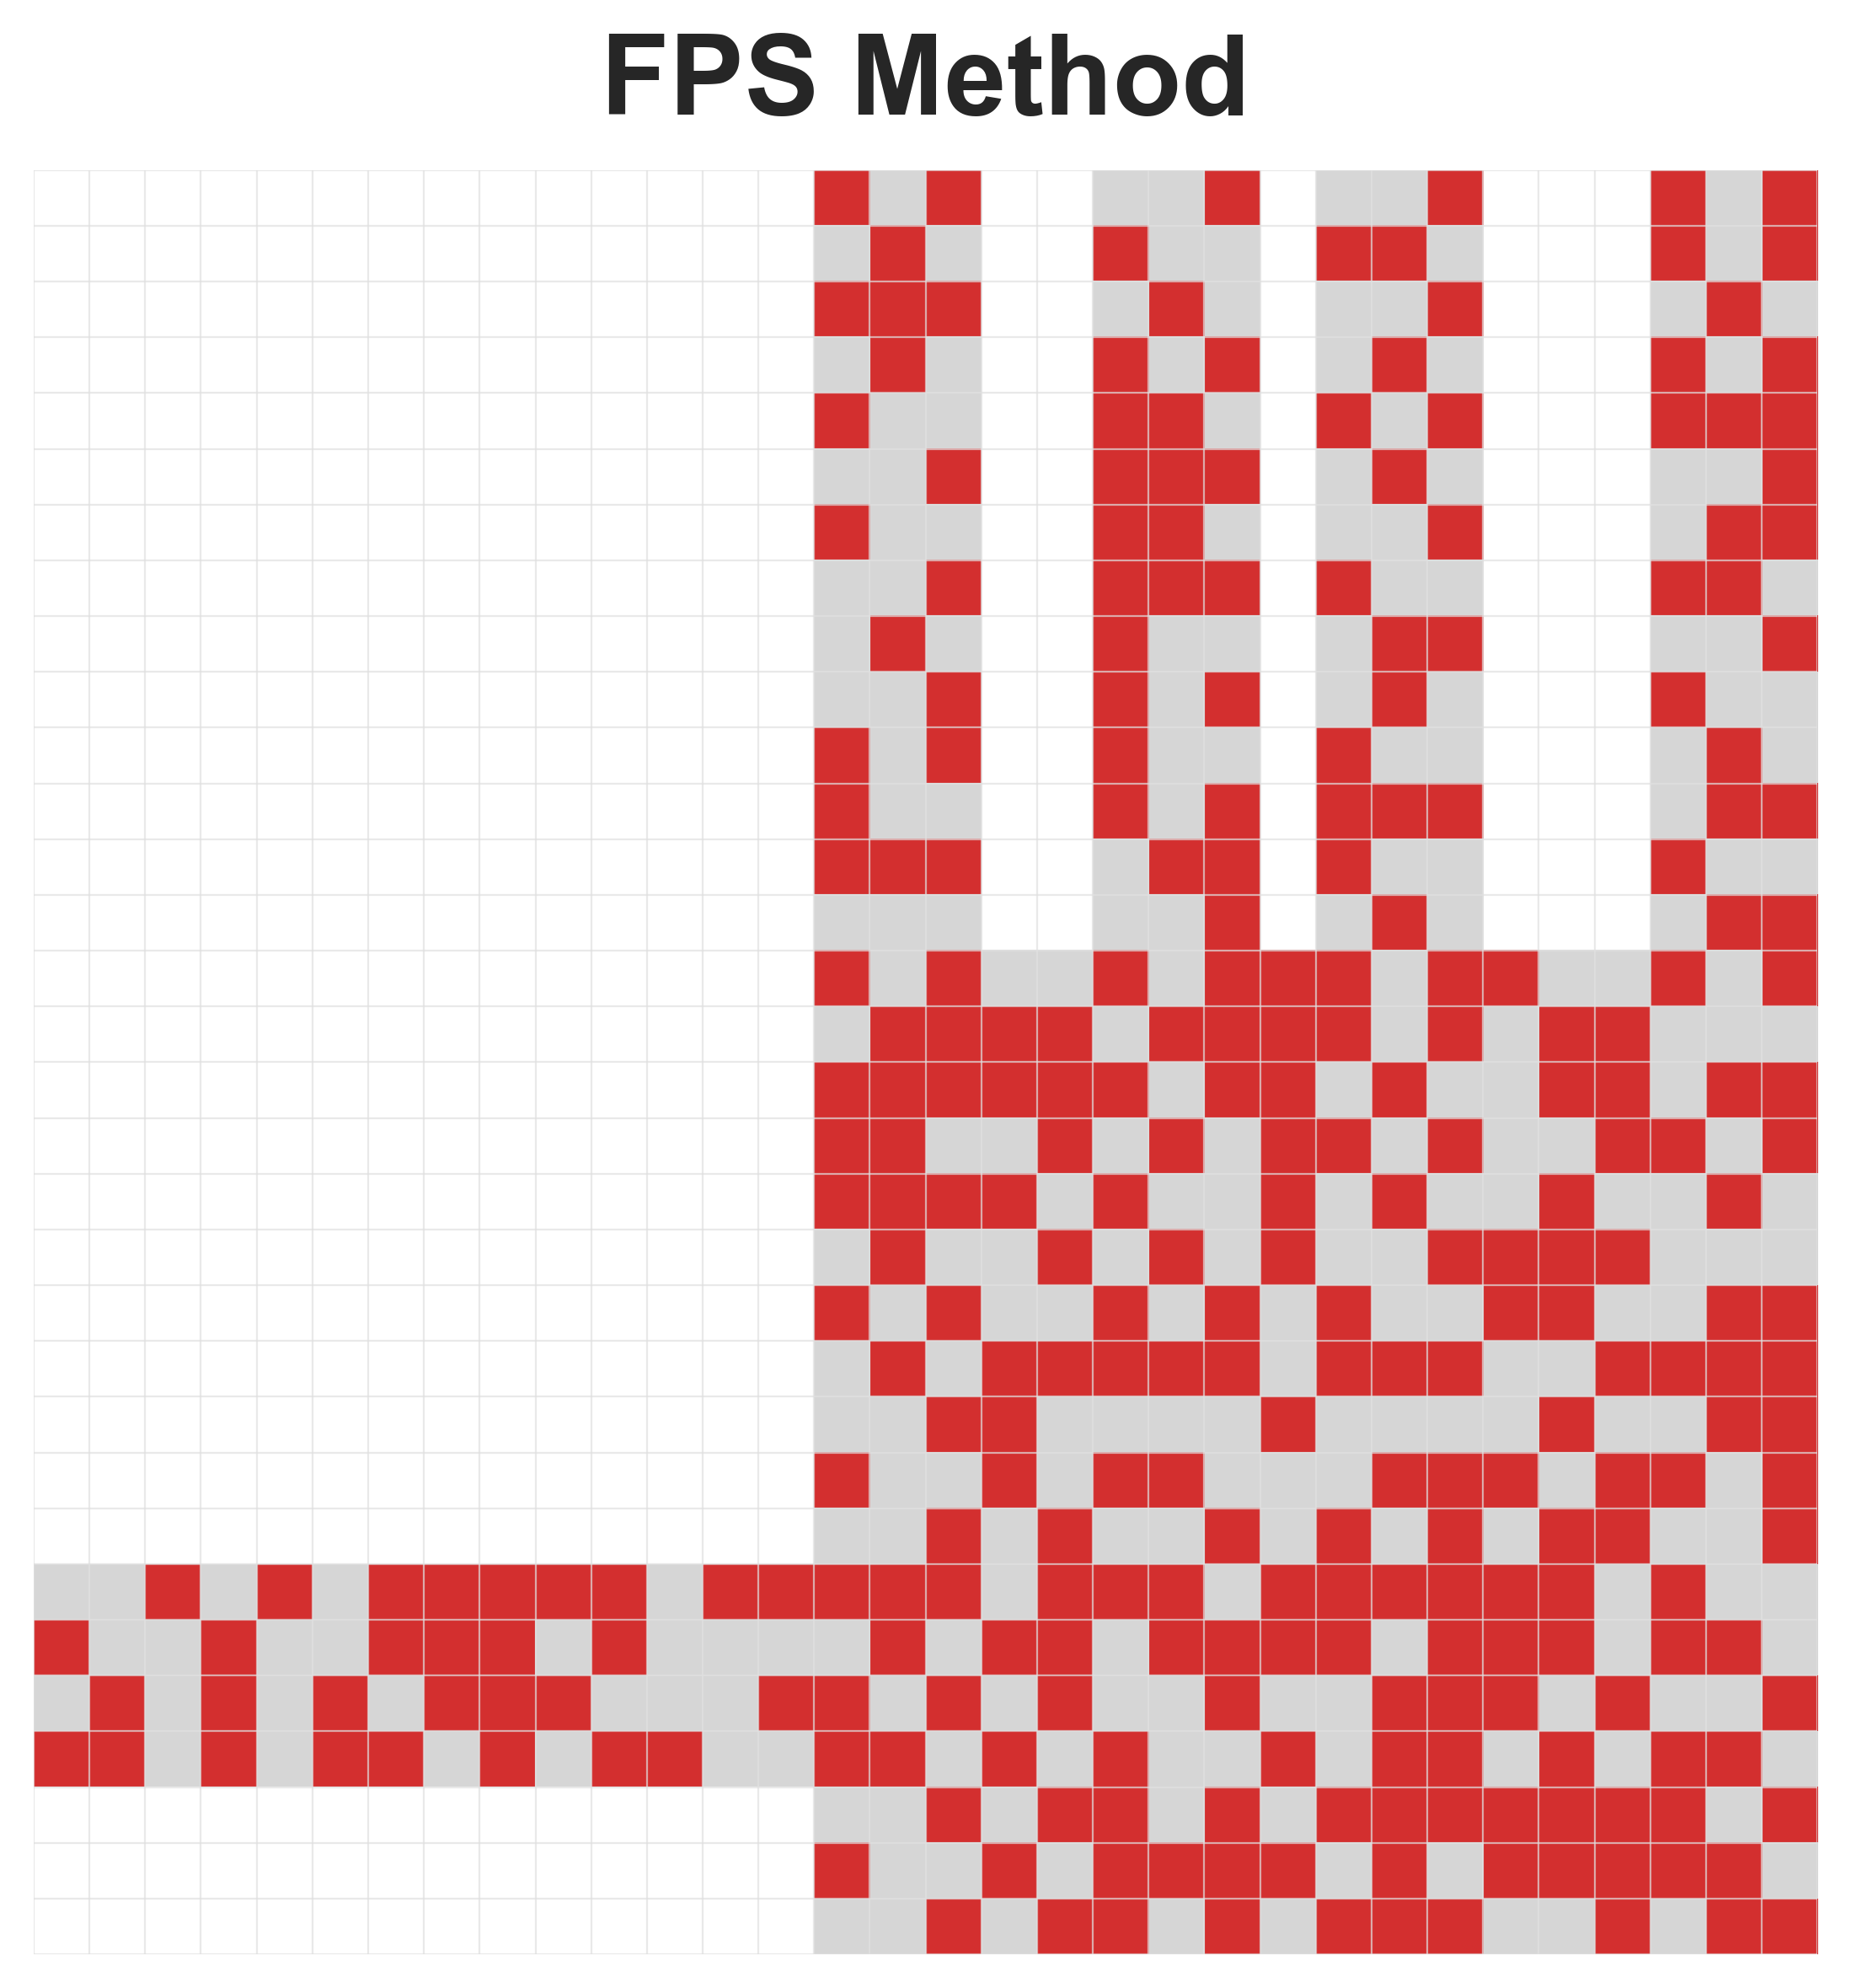

In [2]:
plot_pixel_mask("preprocessed_data/spike_data_method_fps_n_300_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl",
                title="FPS Method",
                save_path="pixel_mask_fps_300")  

Loaded data from preprocessed_data/spike_data_method_topn_n_300_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl with params: {'method': 'topn', 'n': 300, 'num_frames': 25, 'threshold': 0.01, 'session_id': [0, 1], 'channels': 1, 'down_spike': 1.0, 'encoding': 'spike'}


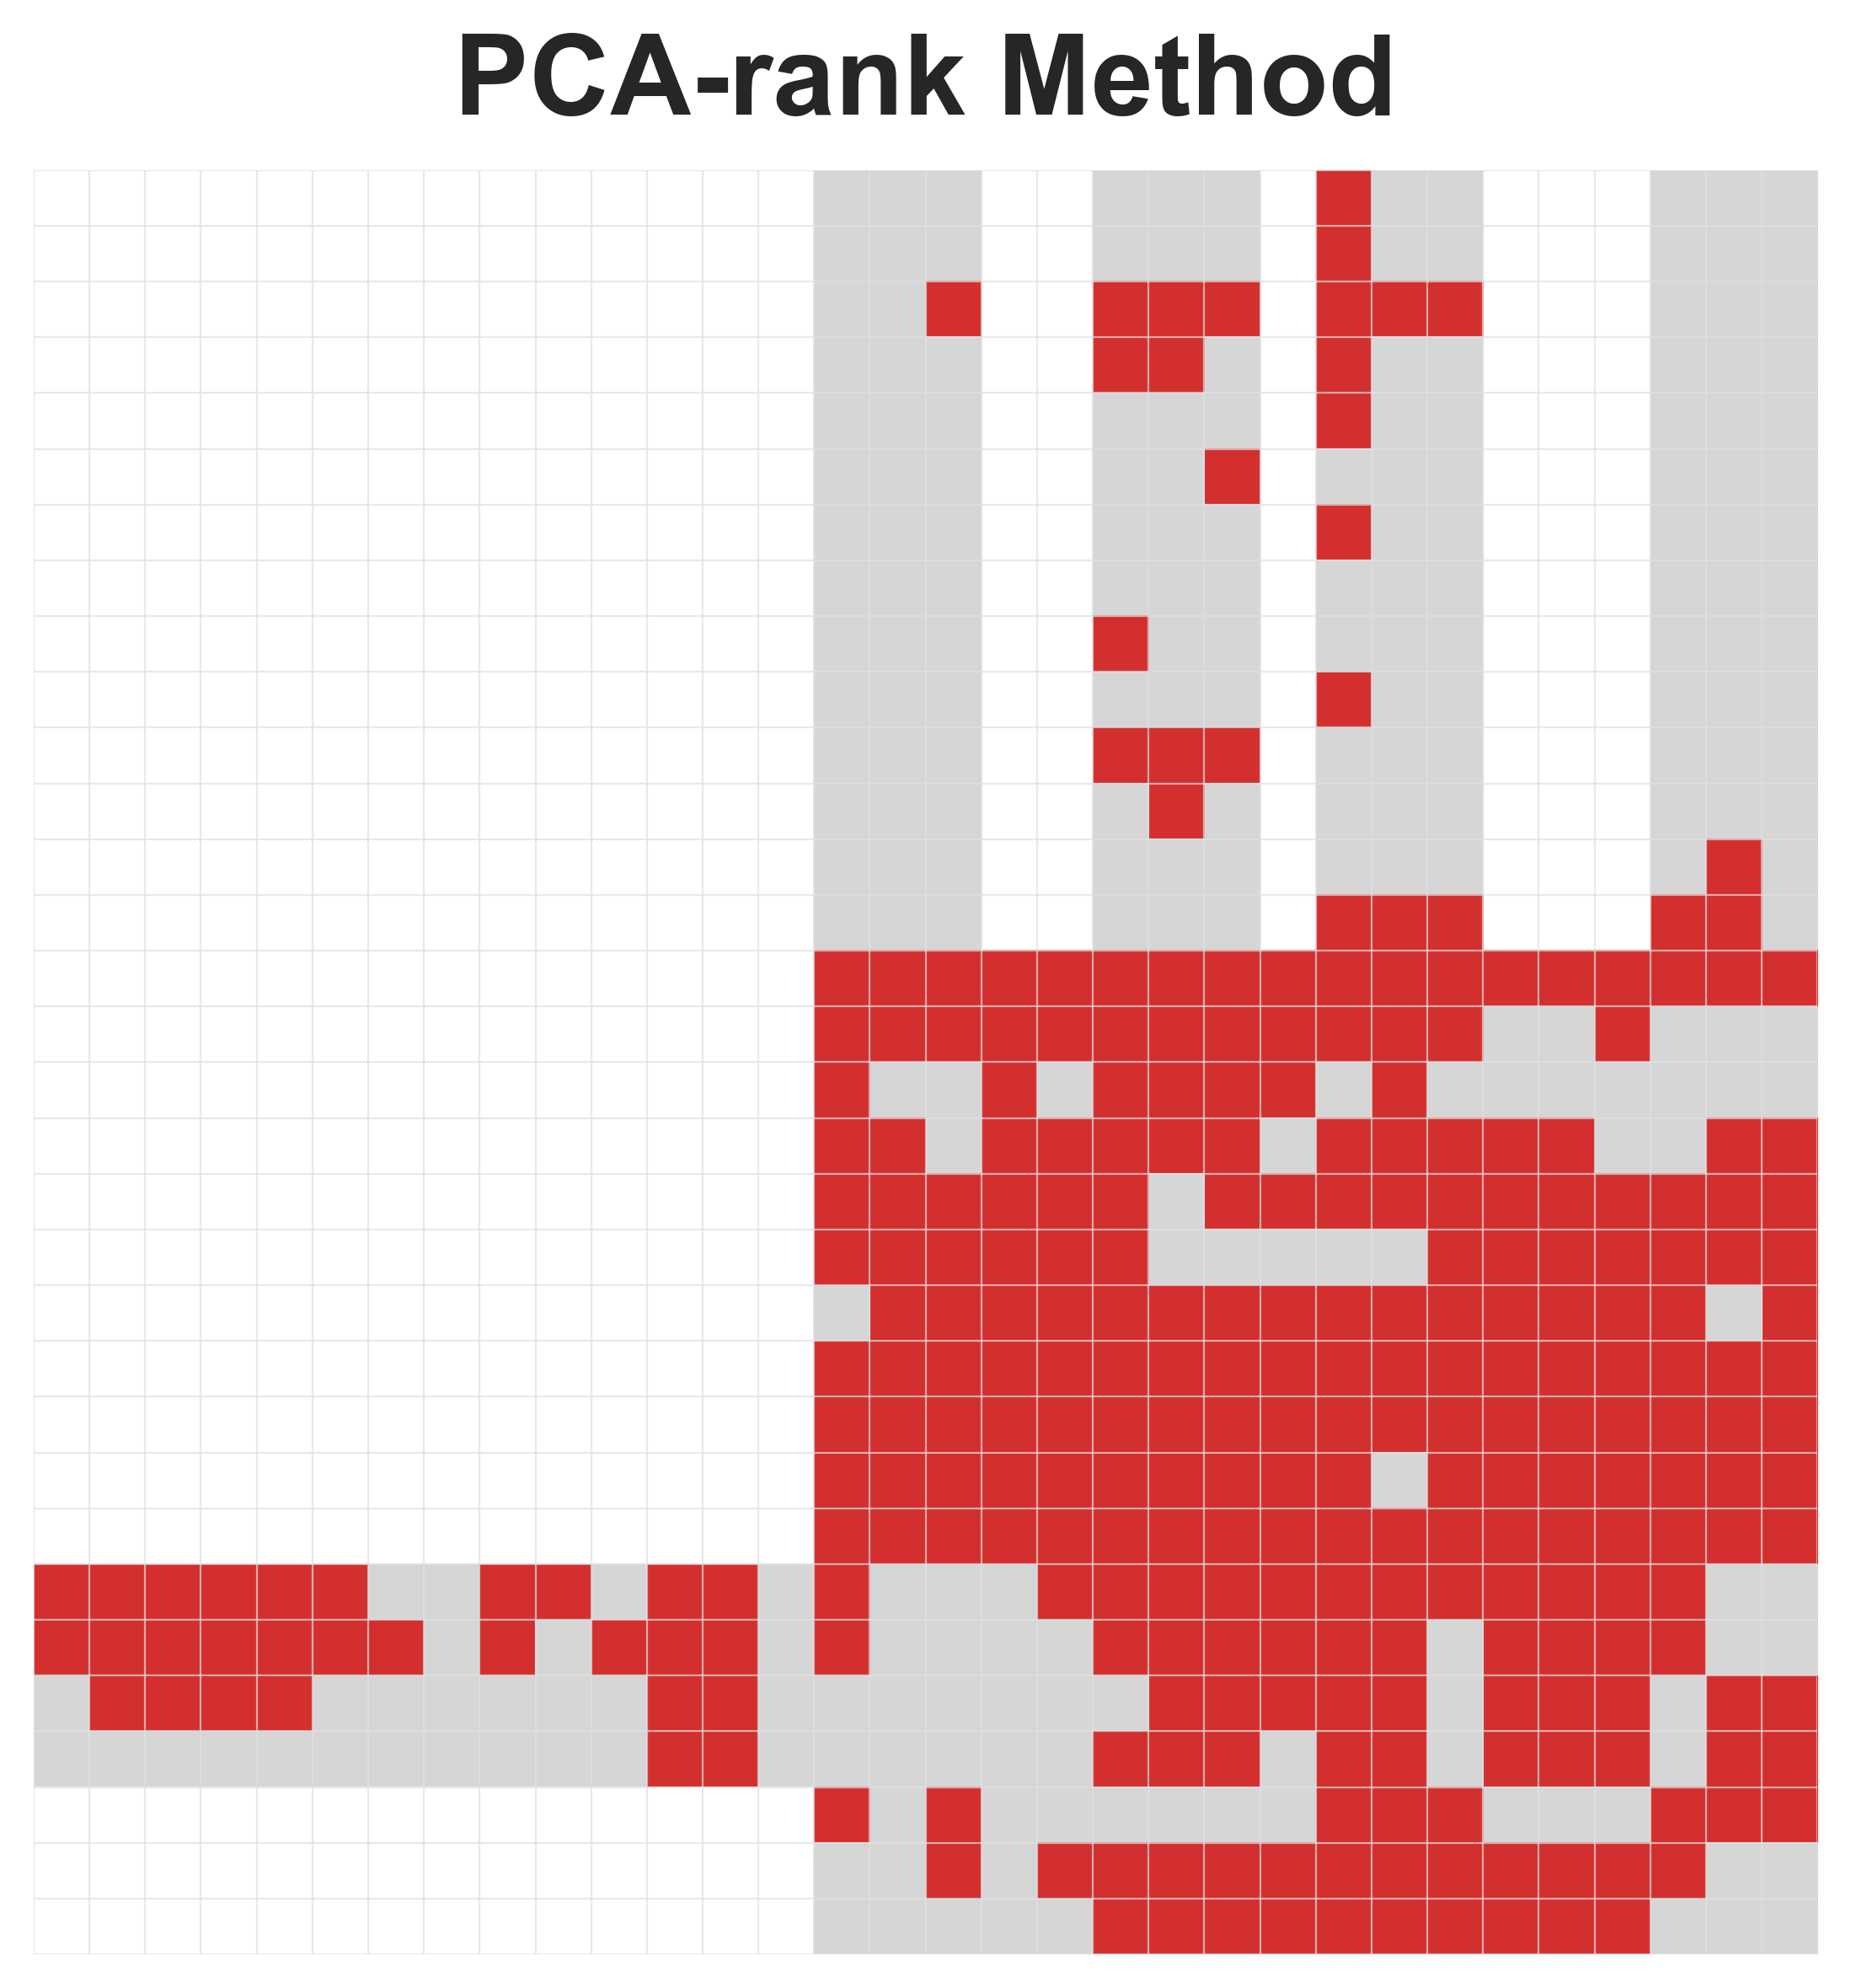

In [3]:
plot_pixel_mask("preprocessed_data/spike_data_method_topn_n_300_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl",
                title="PCA-rank Method",
                save_path="pixel_mask_topn_300")  

Loaded data from preprocessed_data/spike_data_method_random_n_300_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl with params: {'method': 'random', 'n': 300, 'num_frames': 25, 'threshold': 0.01, 'session_id': [0, 1], 'channels': 1, 'down_spike': 1.0, 'encoding': 'spike'}


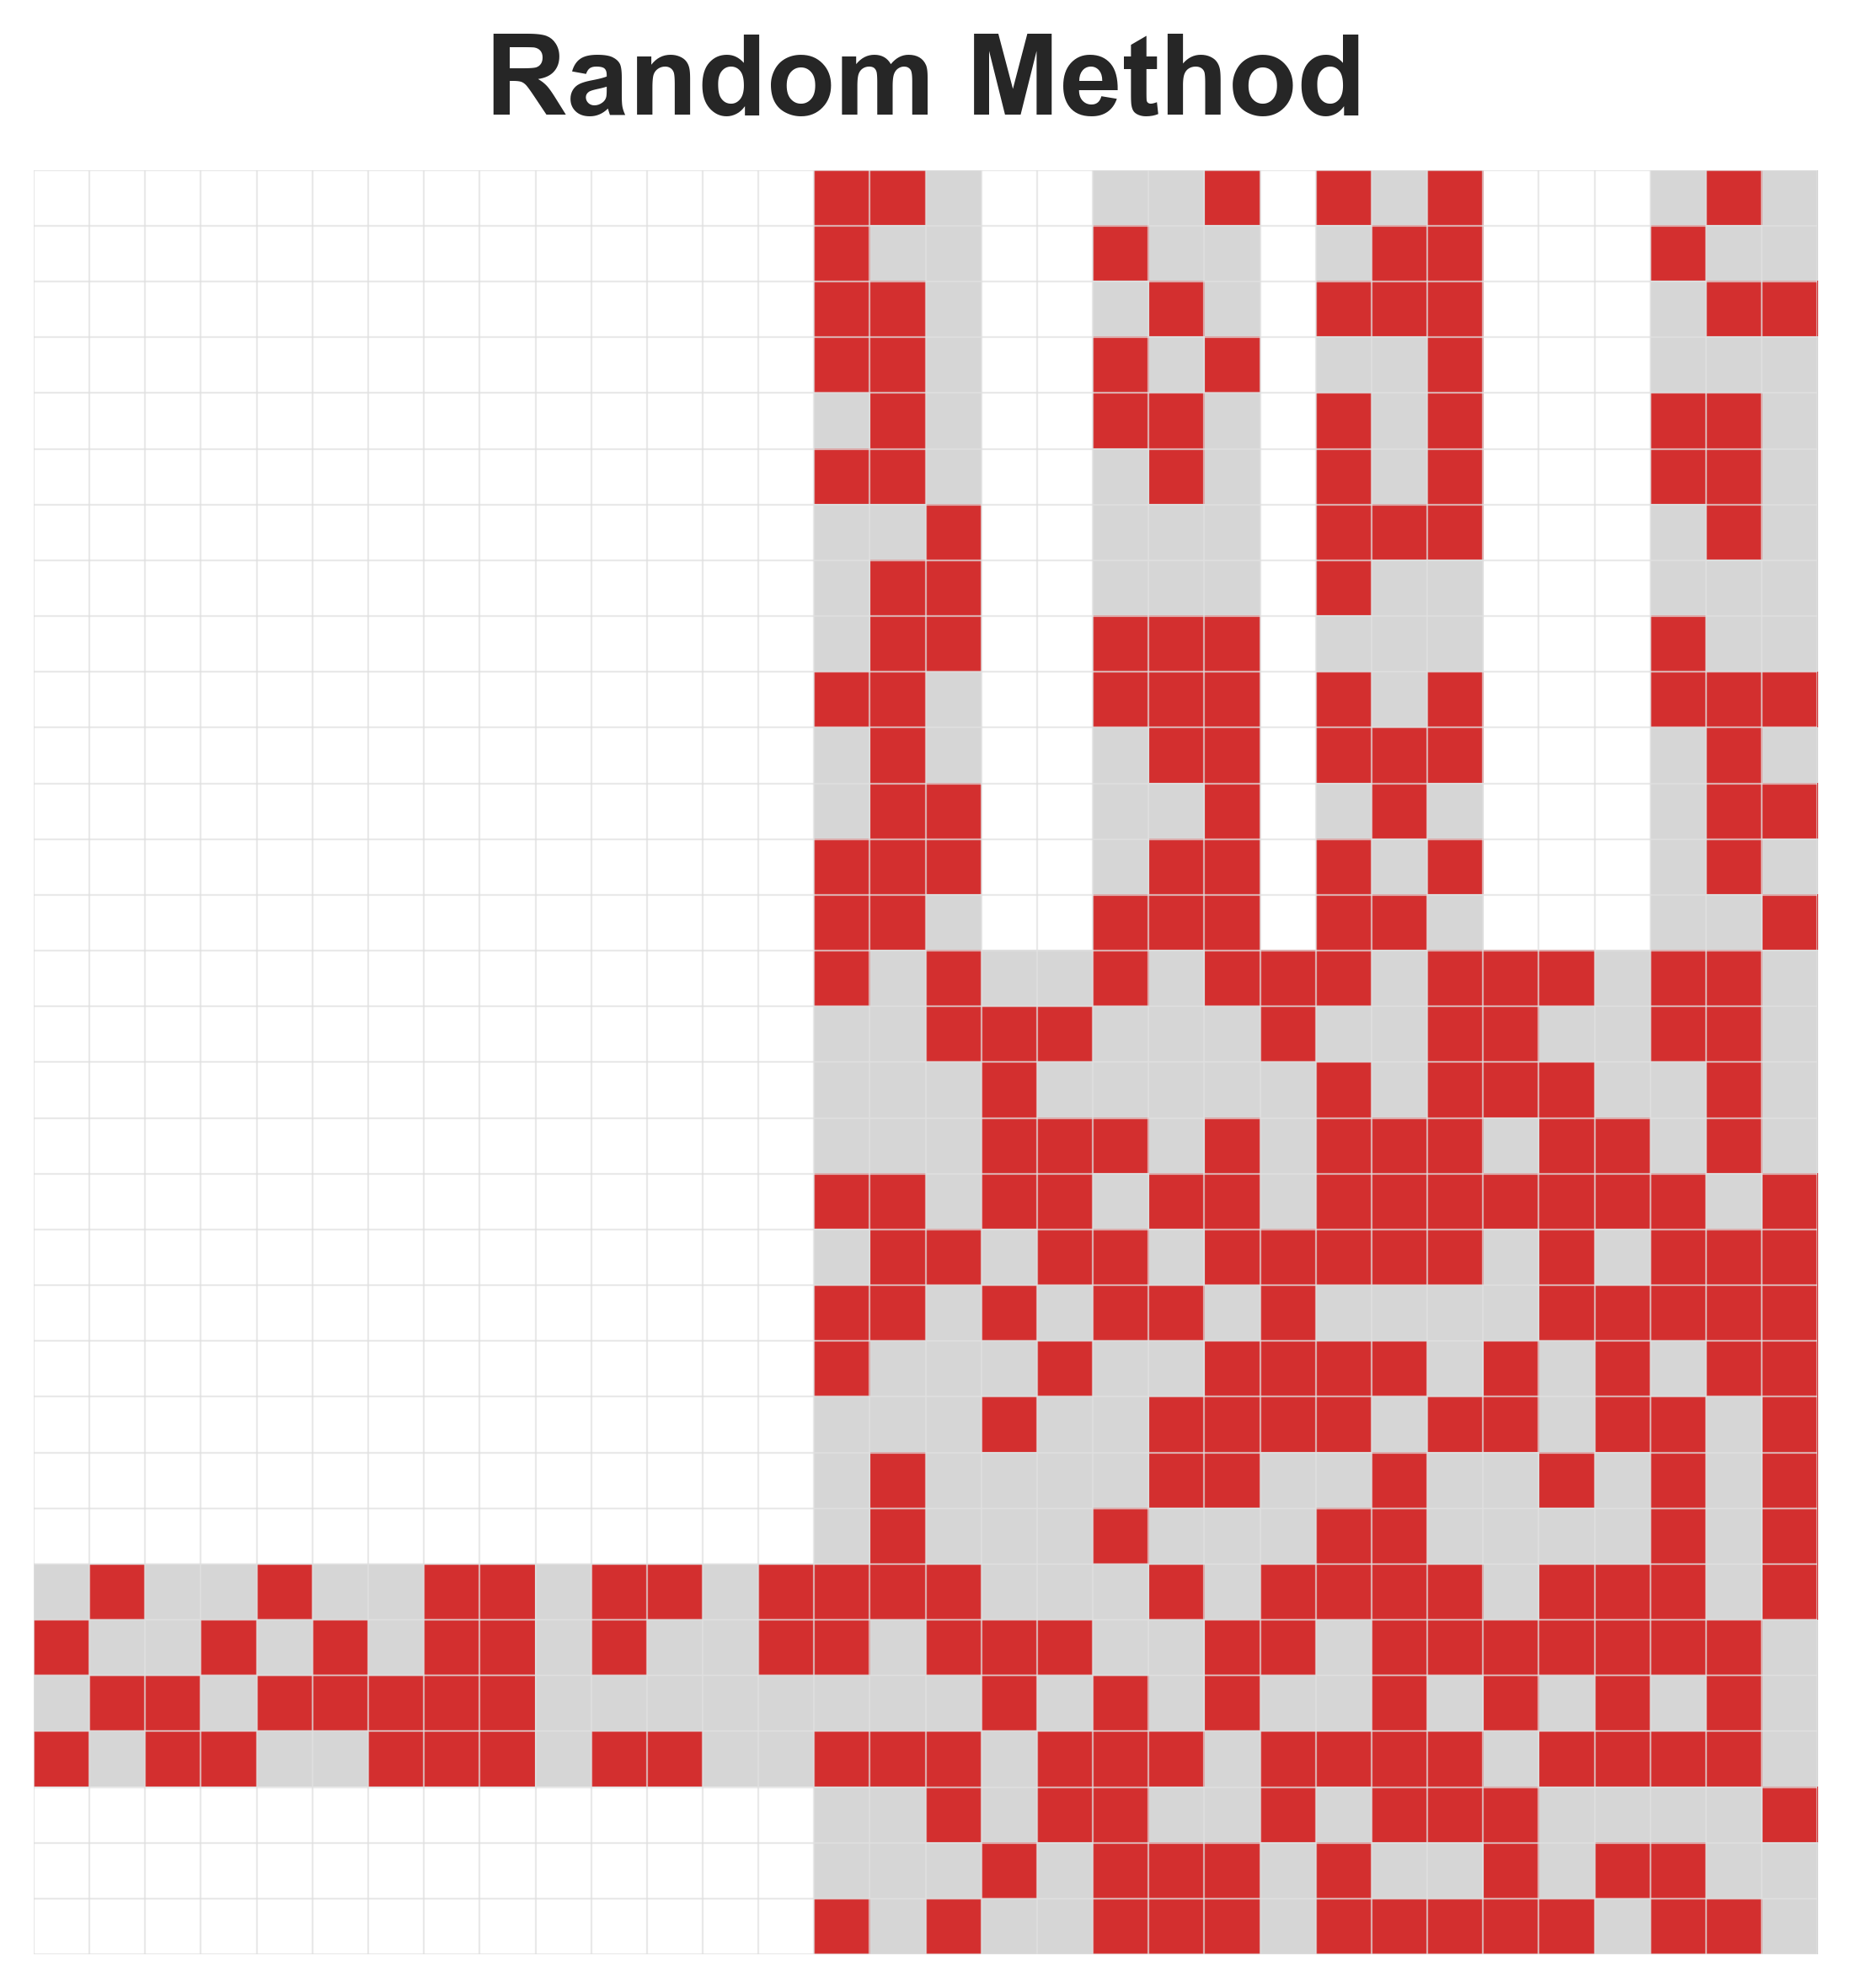

In [4]:
plot_pixel_mask("preprocessed_data/spike_data_method_random_n_300_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl",
                title="Random Method",
                save_path="pixel_mask_random_300")  

Loaded data from preprocessed_data/spike_data_method_custom_n_300_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl with params: {'method': 'custom', 'n': 300, 'num_frames': 25, 'threshold': 0.01, 'session_id': [0, 1], 'channels': 1, 'down_spike': 1.0, 'encoding': 'spike'}


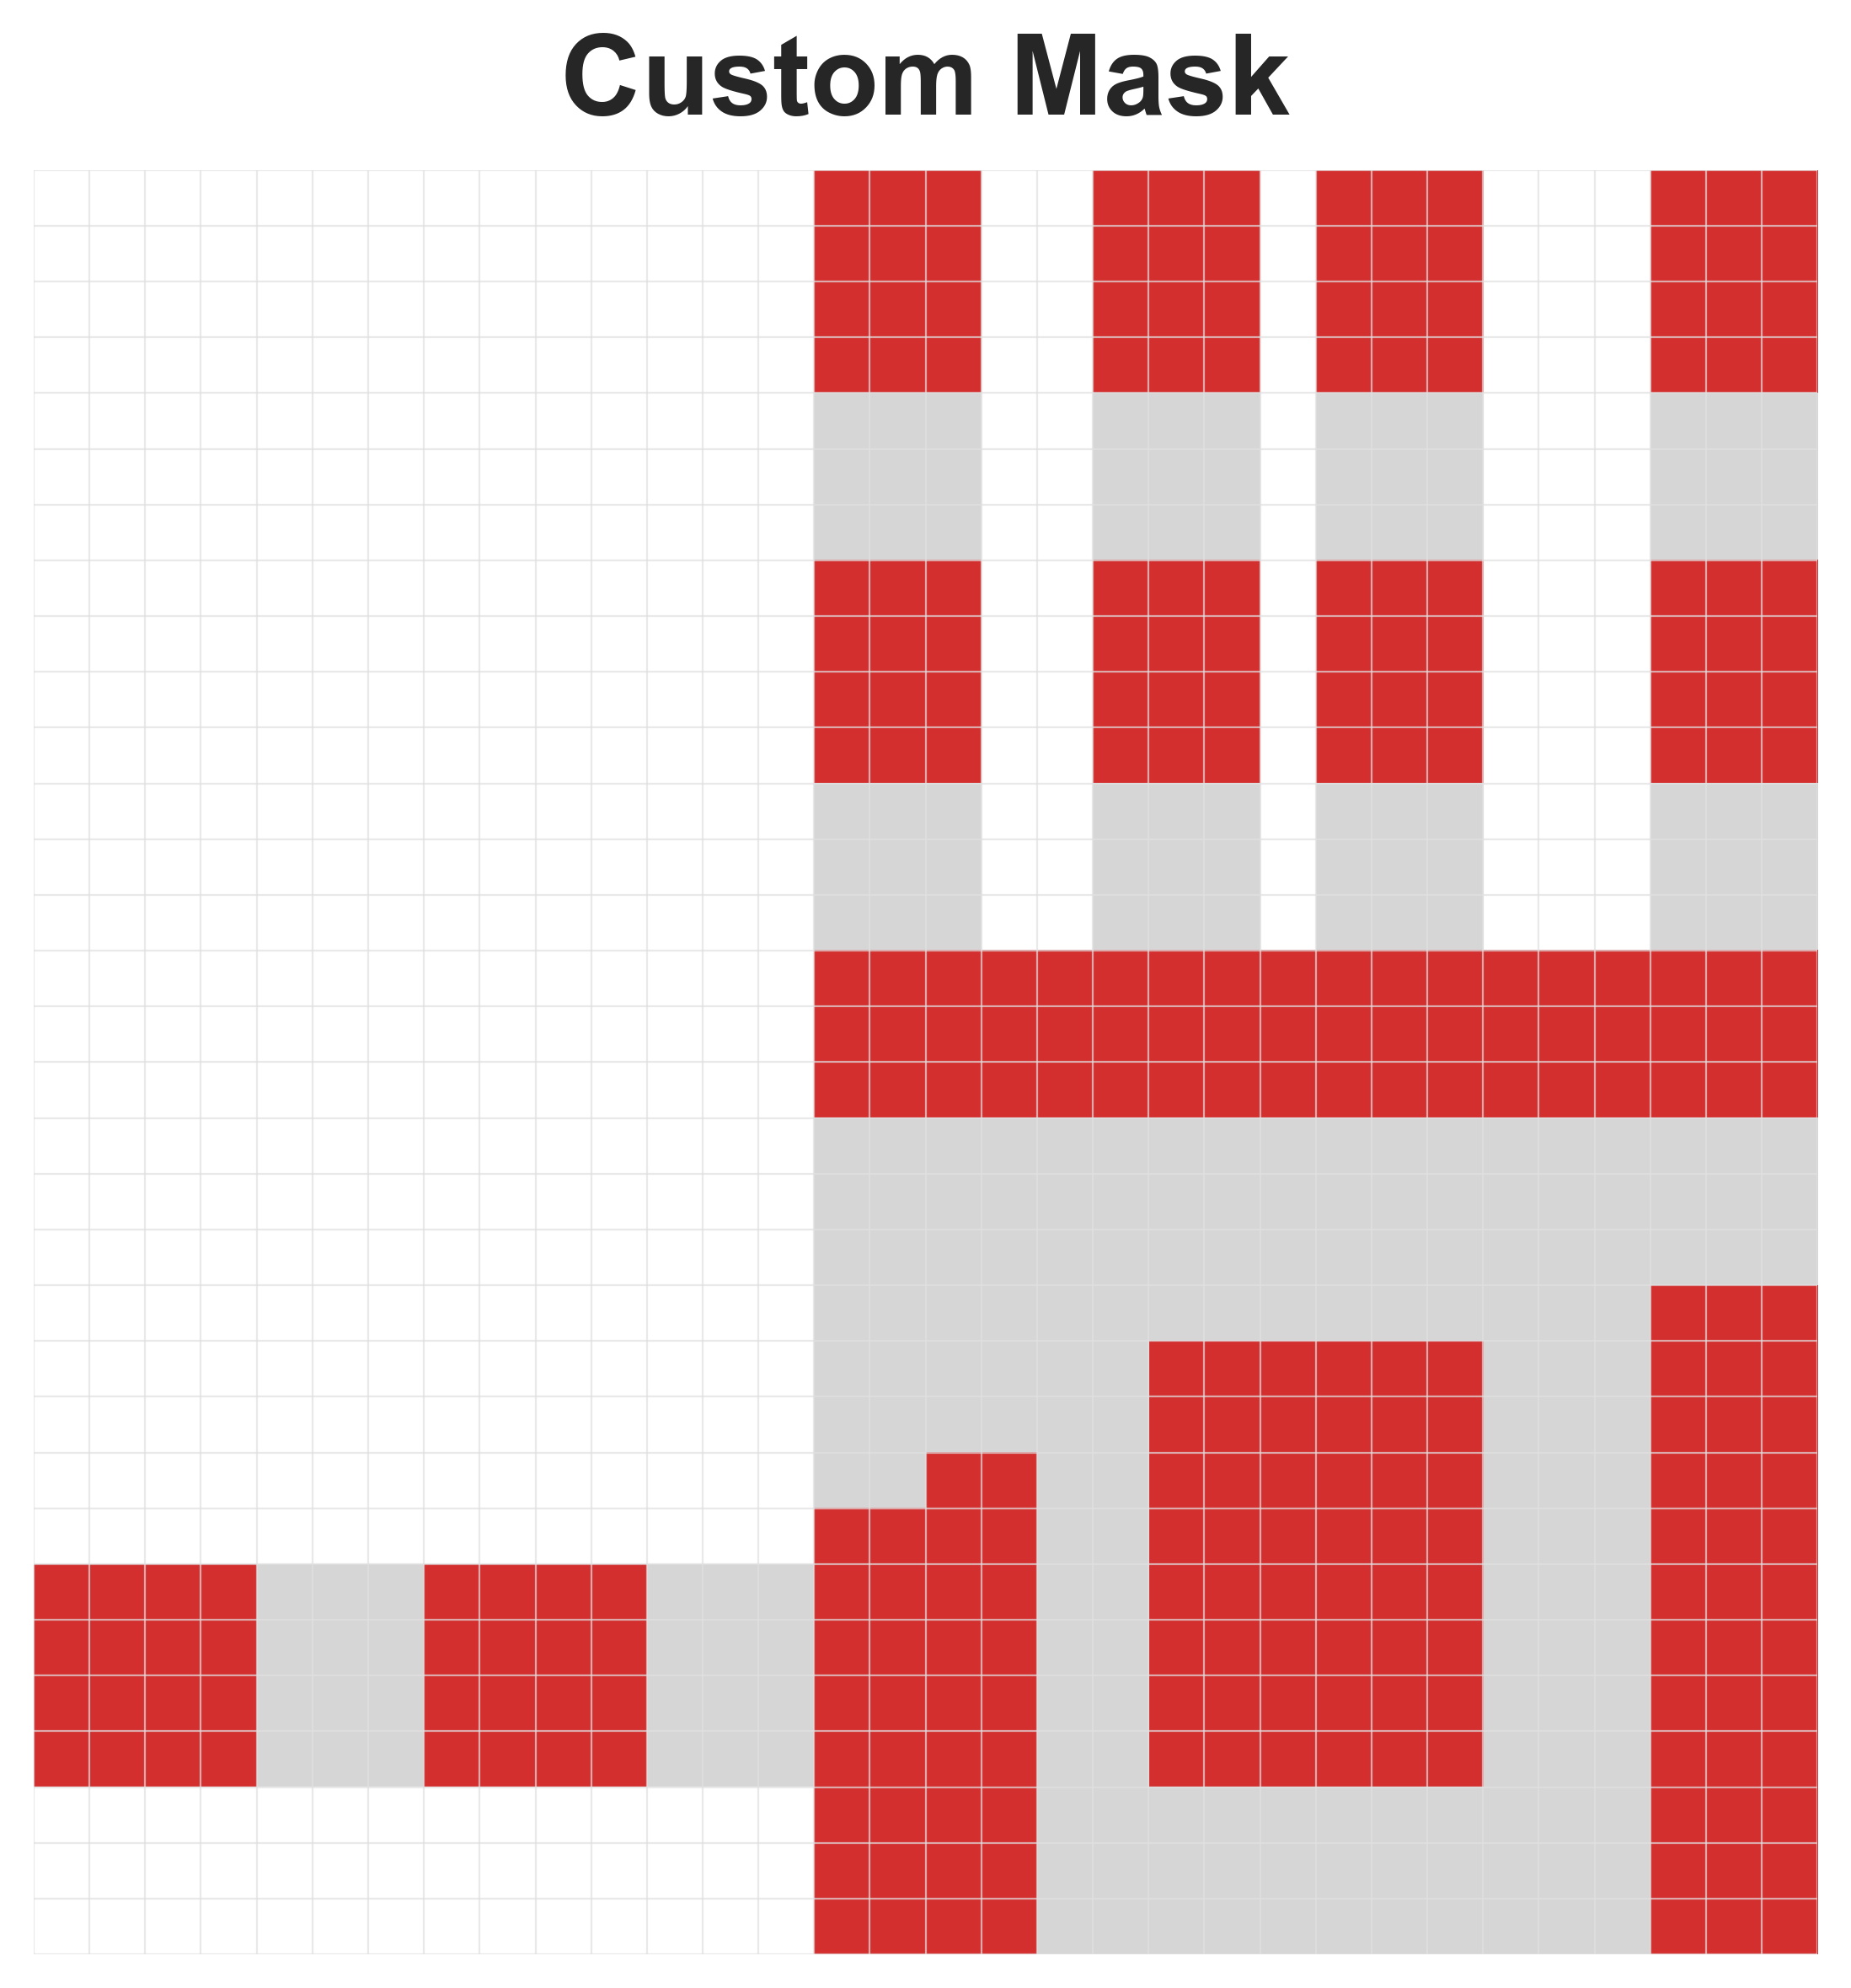

In [3]:
plot_pixel_mask("preprocessed_data/spike_data_method_custom_n_300_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl",
                title="Custom Mask",
                save_path="pixel_mask_custom_300_roi")  

Loaded data from preprocessed_data/spike_data_method_custom_n_274_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl with params: {'method': 'custom', 'n': 274, 'num_frames': 25, 'threshold': 0.01, 'session_id': [0, 1], 'channels': 1, 'down_spike': 1.0, 'encoding': 'spike'}


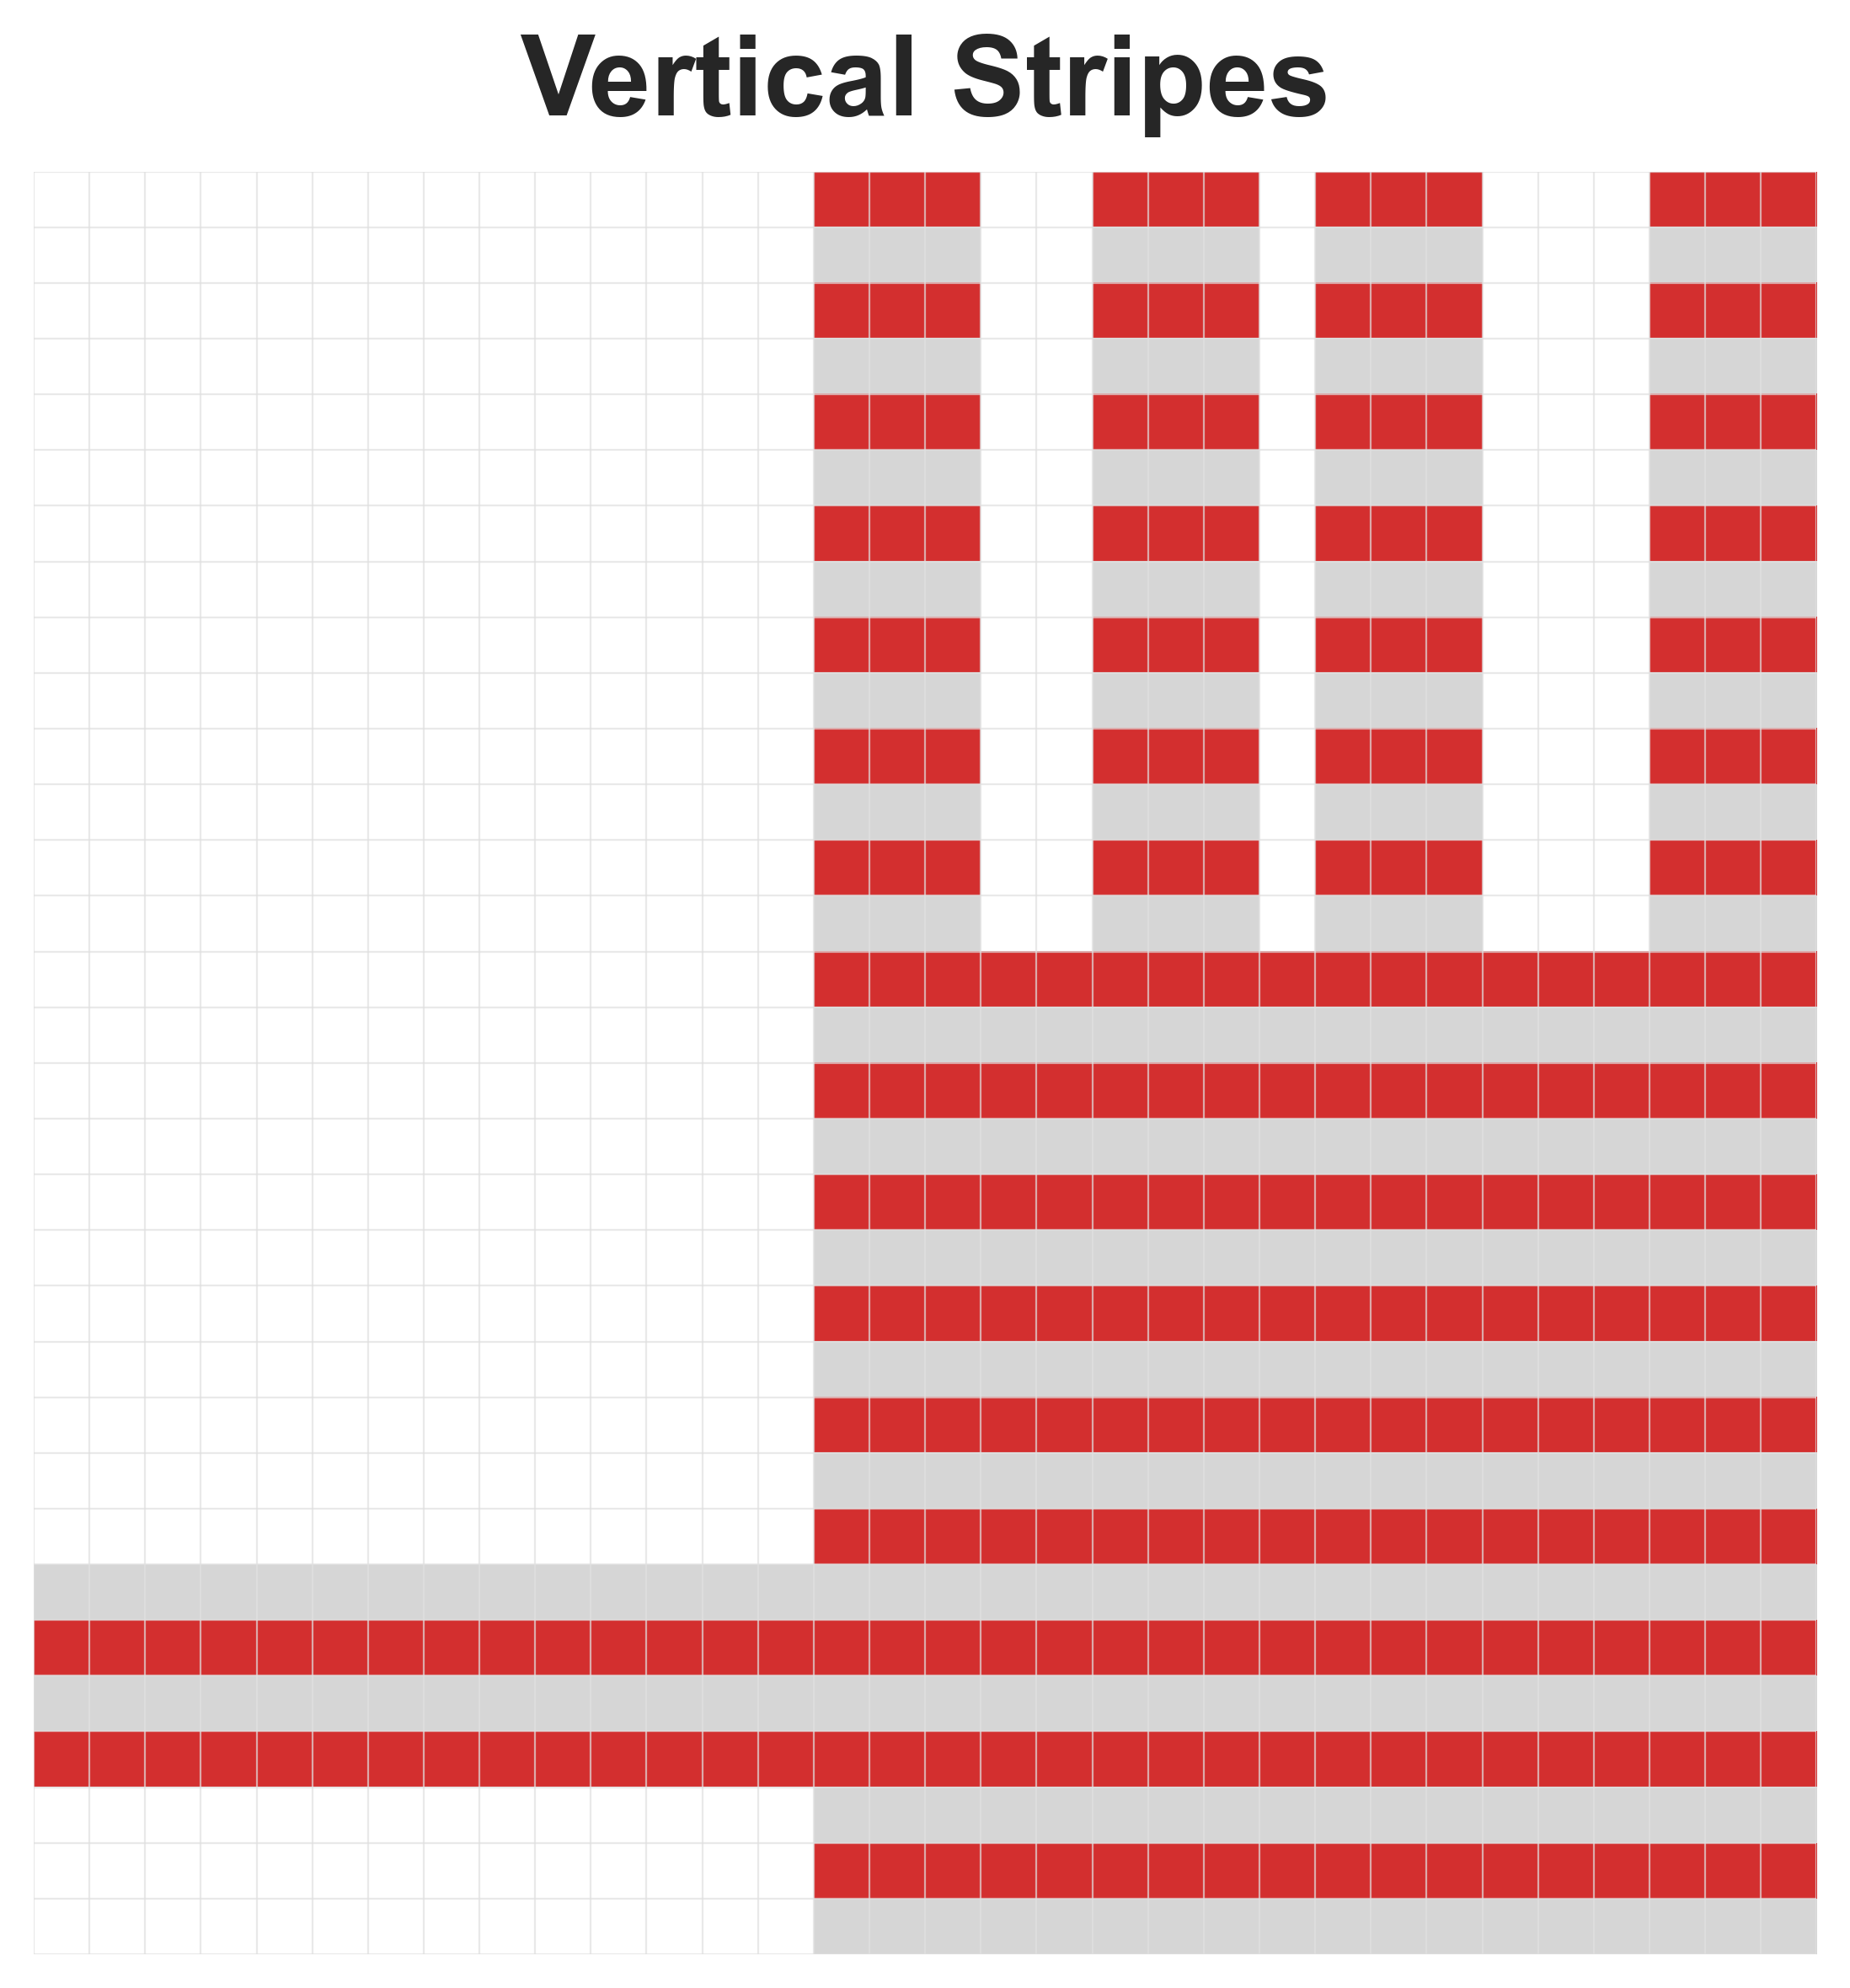

In [6]:
plot_pixel_mask("preprocessed_data/spike_data_method_custom_n_274_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl",
                title="Vertical Stripes",
                save_path="pixel_mask_custom_274")

Loaded data from preprocessed_data/spike_data_method_custom_n_288_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl with params: {'method': 'custom', 'n': 288, 'num_frames': 25, 'threshold': 0.01, 'session_id': [0, 1], 'channels': 1, 'down_spike': 1.0, 'encoding': 'spike'}


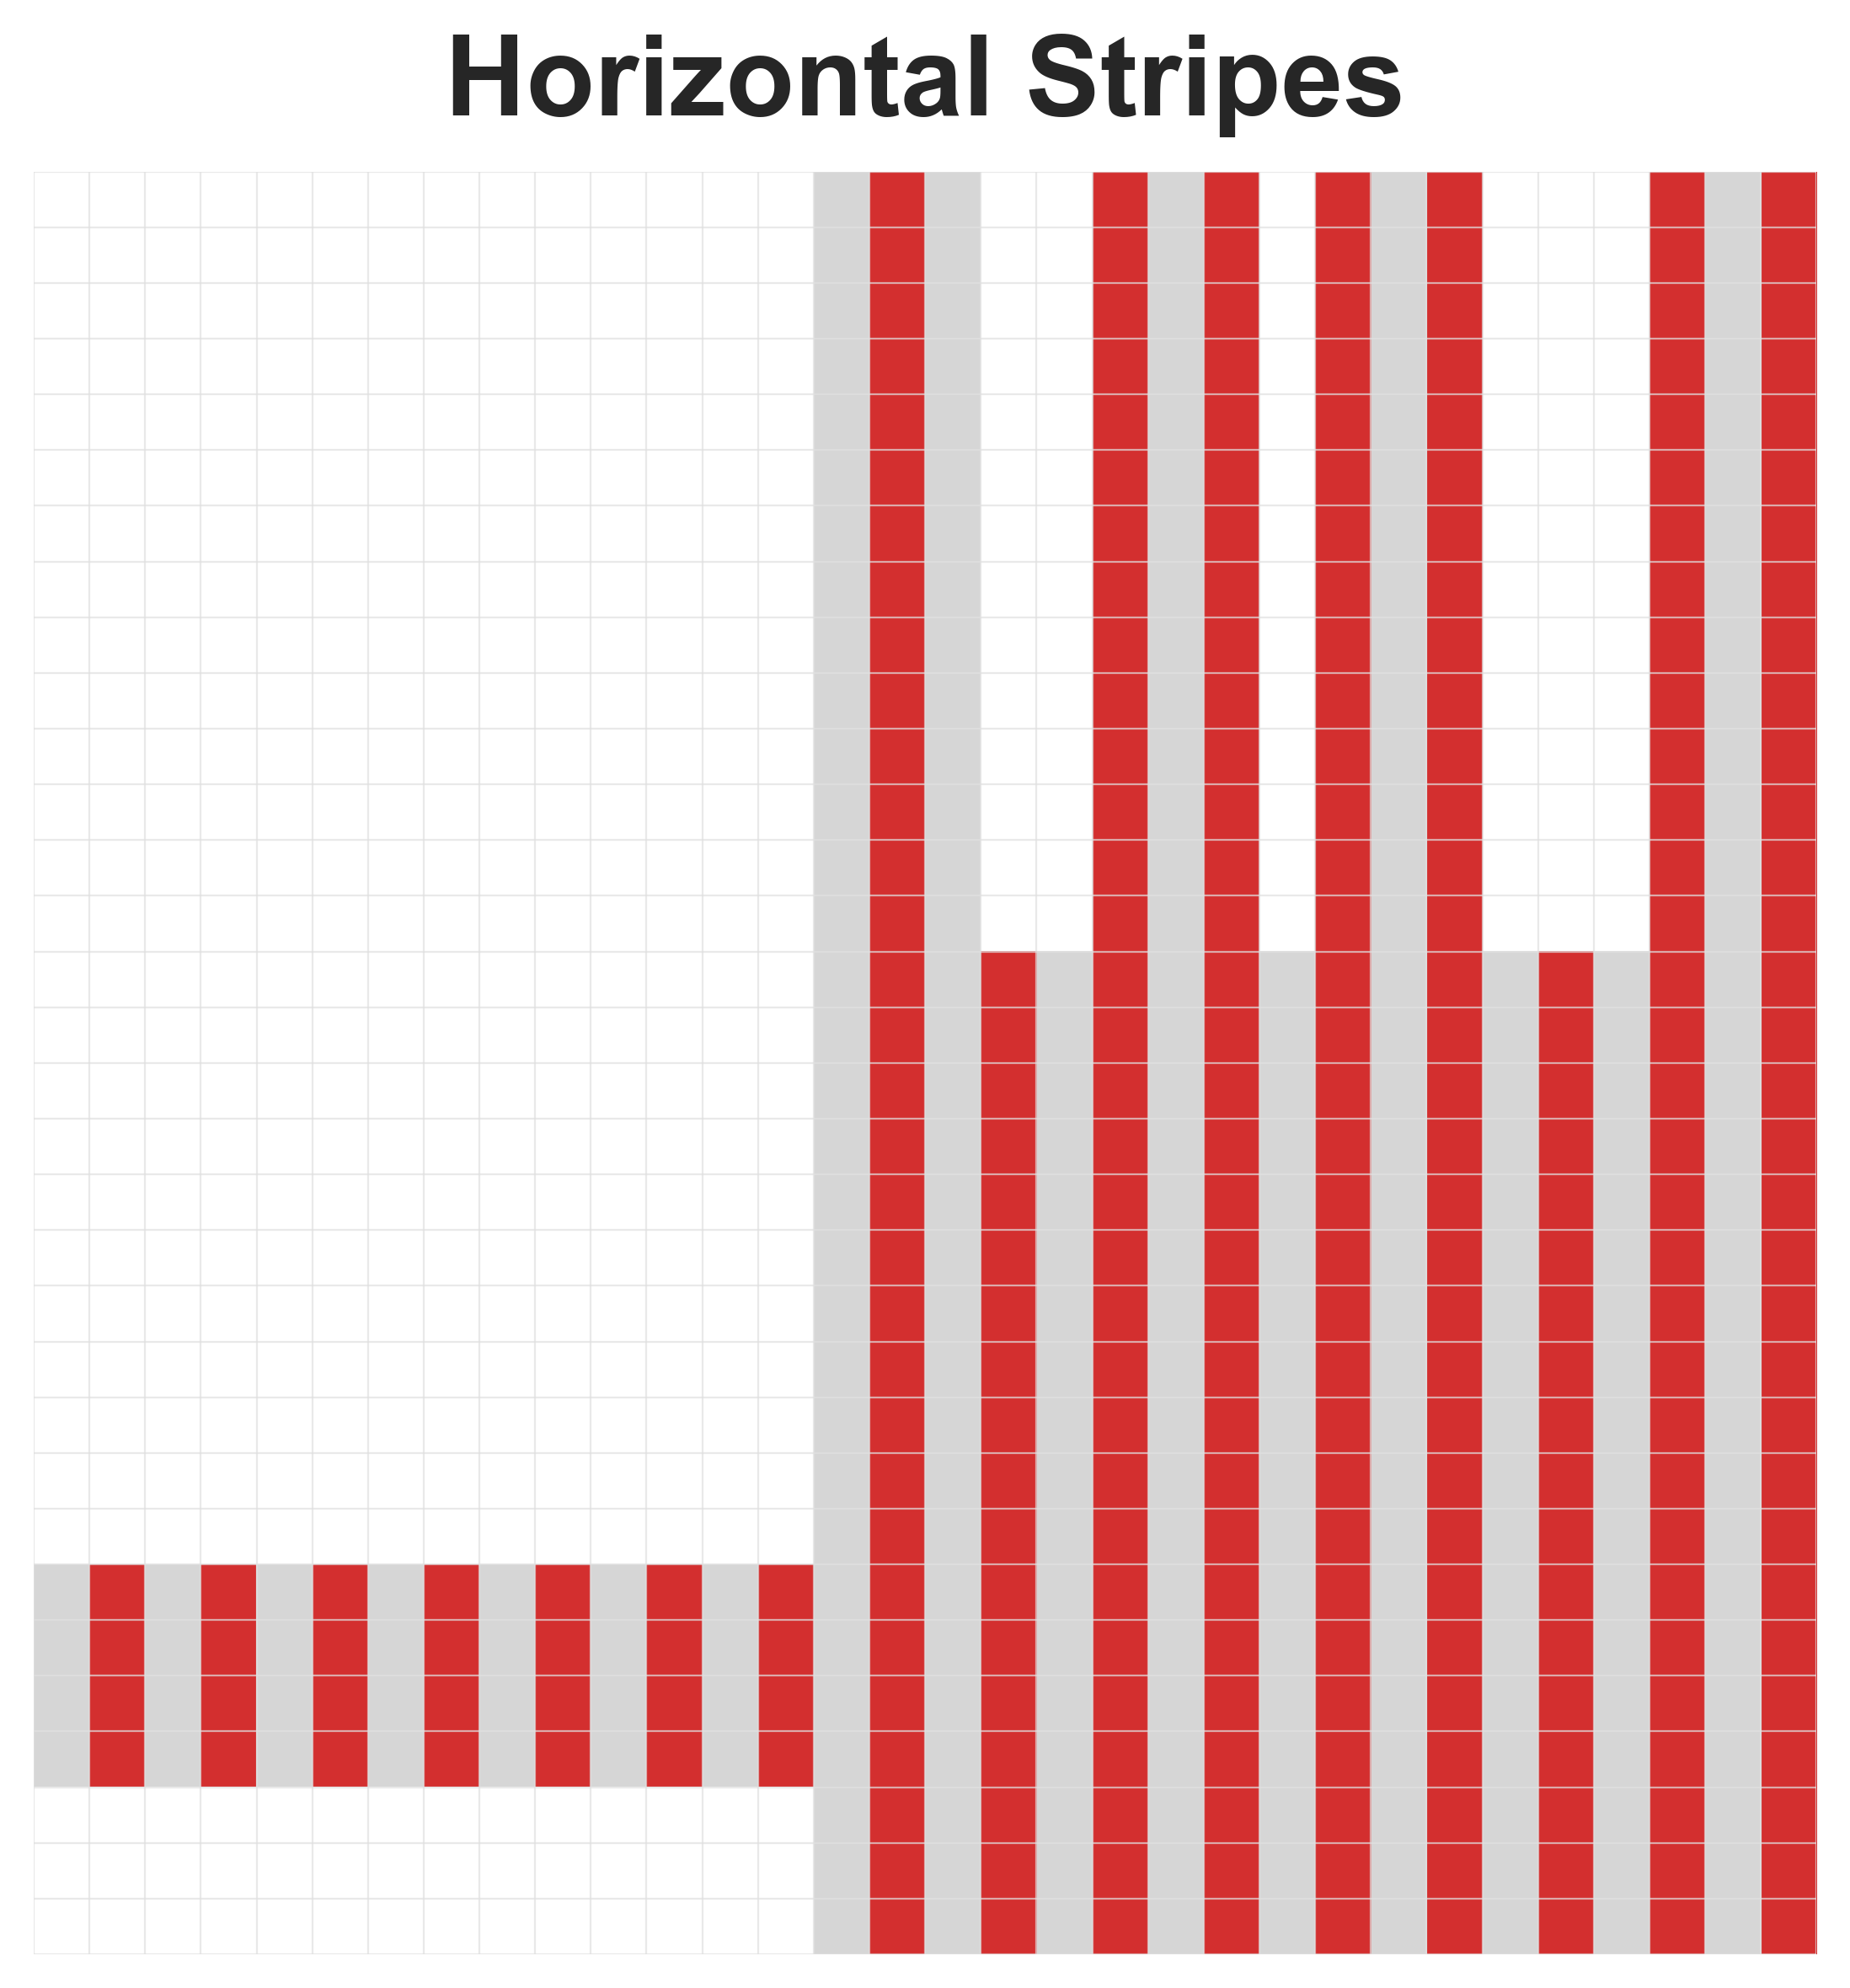

In [7]:
plot_pixel_mask("preprocessed_data/spike_data_method_custom_n_288_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl",
                title="Horizontal Stripes",
                save_path="pixel_mask_custom_288")

In [ ]:
app = PixelSelectorUI()

In [ ]:
load_spike_data("preprocessed_data/spike_data_method_average_n_322222_num_frames_25_threshold_0.01_channels_1_down_spike_1.0_encoding_spike_session_id_0_1.pkl")[0].shape

Built Averager: 151 Super-Pixels created.


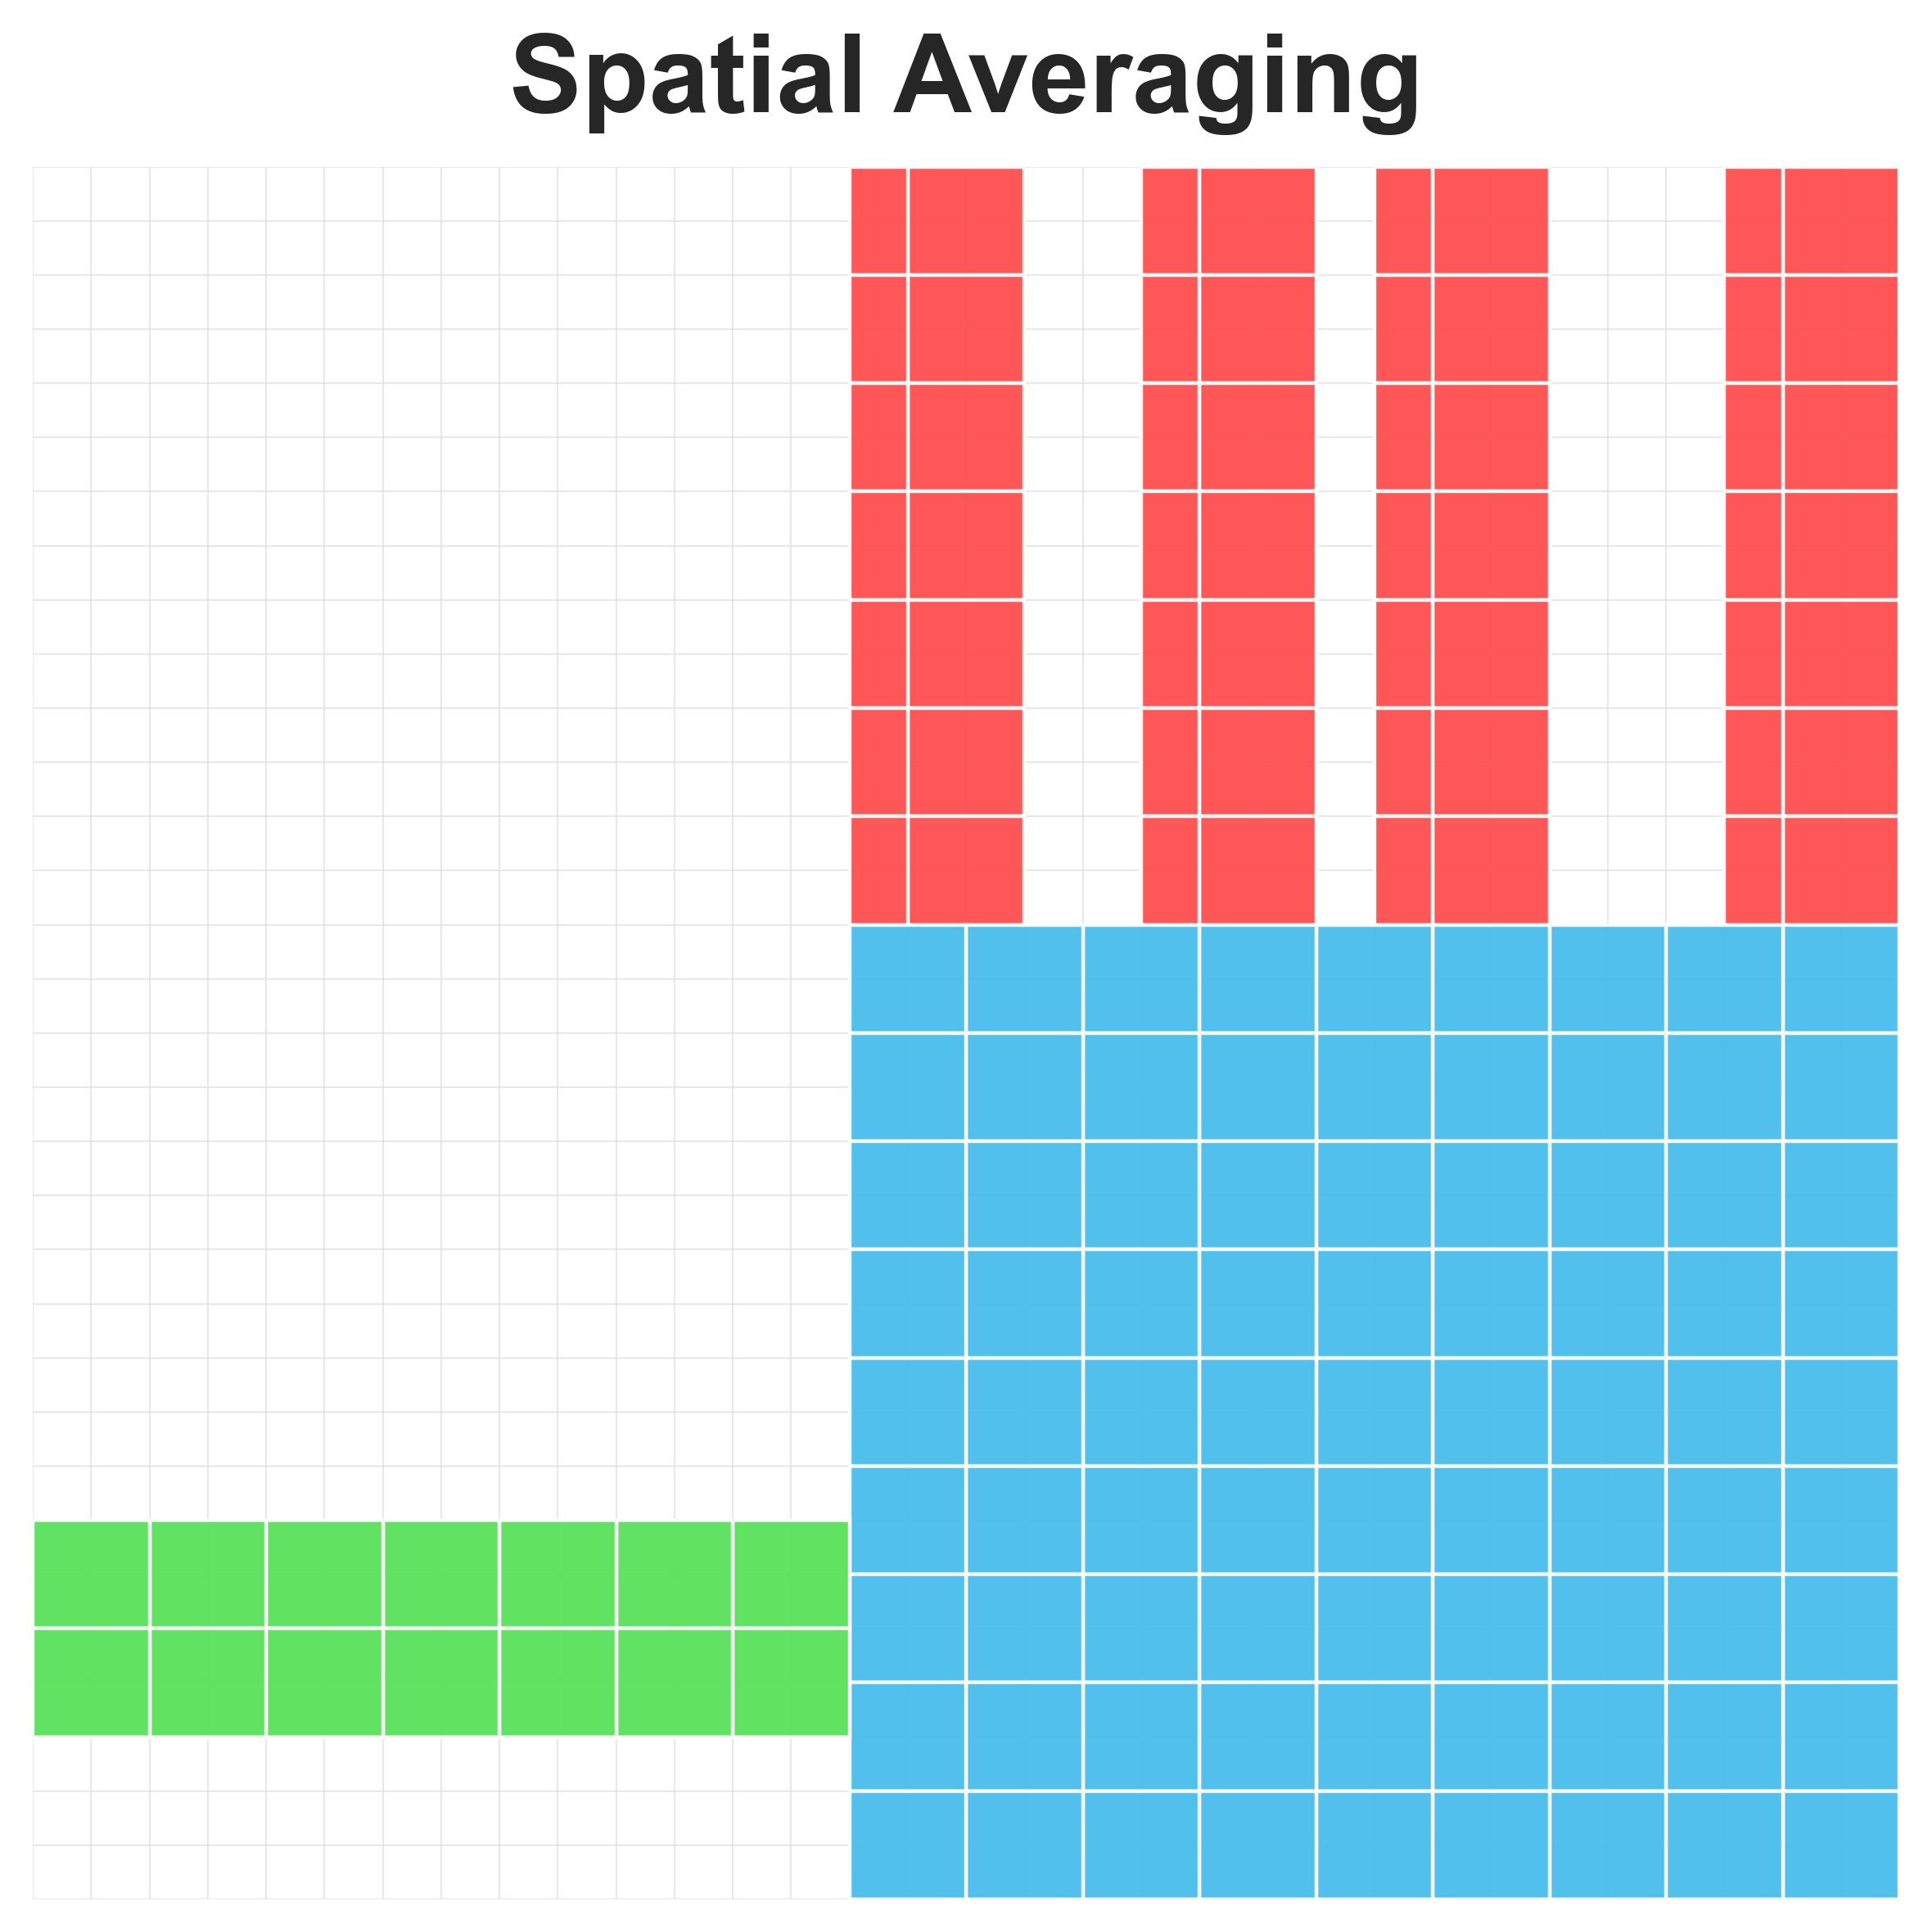

In [ ]:
averager = SmartHandAverager(
    finger_kernel=(2, 2), 
    palm_kernel=(2, 2), 
    thumb_kernel=(2, 2)
)
averager.plot_layout(title='Spatial Averaging', )

## FPS Selection Animation (32x32 Hand Mask)

This animation shows how Farthest Point Sampling progressively selects taxels on the hand mask.

- Light gray: valid hand pixels
- White: invalid pixels
- Red: selected pixels up to the current FPS step

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from scipy.spatial.distance import cdist
import ipywidgets as widgets
from IPython.display import display

from utils import get_hand_mask_548

# Use an interactive backend when available so artist updates are smooth.
try:
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass


def fps_indices_with_history(n_points=120, seed=42):
    """Run FPS on valid hand taxels and return selected global indices in order."""
    valid_indices = np.where(get_hand_mask_548())[0]
    rows = valid_indices // 32
    cols = valid_indices % 32
    coords = np.stack([rows, cols], axis=1).astype(np.float32)

    num_valid = len(valid_indices)
    if n_points >= num_valid:
        return valid_indices

    rng = np.random.default_rng(seed=seed)
    first_idx = rng.integers(0, num_valid)

    selected_local = [first_idx]
    dists = cdist(coords, coords[first_idx:first_idx + 1], metric="euclidean").flatten()

    for _ in range(n_points - 1):
        # Small jitter avoids deterministic ties for symmetric points.
        farthest_idx = np.argmax(dists + rng.uniform(-1e-9, 1e-9, size=len(dists)))
        selected_local.append(farthest_idx)
        new_dists = cdist(coords, coords[farthest_idx:farthest_idx + 1], metric="euclidean").flatten()
        dists = np.minimum(dists, new_dists)

    return valid_indices[np.array(selected_local)]


def fps_selection_player(n_points=120, seed=42, interval=120):
    """Smooth FPS player: static base image + dynamic red overlay only."""
    valid_grid = get_hand_mask_548().reshape(32, 32)
    selected_global = fps_indices_with_history(n_points=n_points, seed=seed)

    # Base layer: 0 invalid (white), 1 valid (light gray)
    base_grid = np.zeros((32, 32), dtype=np.uint8)
    base_grid[valid_grid] = 1
    base_cmap = mcolors.ListedColormap(["white", "#d6d6d6"])

    # Overlay layer: NaN transparent, 1 red selected
    overlay_grid = np.full((32, 32), np.nan, dtype=float)
    overlay_cmap = mcolors.ListedColormap(["#d32f2f"])
    overlay_cmap.set_bad((0, 0, 0, 0))

    rr = selected_global // 32
    cc = selected_global % 32

    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.imshow(base_grid, cmap=base_cmap, origin="upper", interpolation="none", vmin=0, vmax=1)
    overlay_im = ax.imshow(overlay_grid, cmap=overlay_cmap, origin="upper", interpolation="none", vmin=1, vmax=1)

    ax.set_xticks(np.arange(-0.5, 32, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 32, 1), minor=True)
    ax.grid(which="minor", color="#c8c8c8", linestyle="-", linewidth=0.35, alpha=0.7)
    ax.tick_params(which="minor", size=0)
    ax.set_xticks([])
    ax.set_yticks([])
    title = ax.set_title(f"FPS Method - Step 1/{len(selected_global)}", fontsize=15, fontweight="semibold", pad=10)

    def update(step):
        # Only update newly selected red pixels; base layer never redraws.
        overlay_grid[:] = np.nan
        overlay_grid[rr[: step + 1], cc[: step + 1]] = 1.0
        overlay_im.set_data(overlay_grid)
        title.set_text(f"FPS Method - Step {step + 1}/{len(selected_global)}")
        fig.canvas.draw_idle()

    play = widgets.Play(value=0, min=0, max=len(selected_global) - 1, step=1, interval=interval, description="Play")
    slider = widgets.IntSlider(value=0, min=0, max=len(selected_global) - 1, step=1, description="Step", readout=True)
    widgets.jslink((play, "value"), (slider, "value"))
    slider.observe(lambda change: update(change["new"]), names="value")

    controls = widgets.HBox([play, slider])

    canvas_module = type(fig.canvas).__module__
    if "ipympl" in canvas_module:
        display(widgets.VBox([controls, fig.canvas]))
    else:
        display(controls)
        display(fig)

    # Prevent duplicate auto-display in inline backends.
    plt.close(fig)

    update(0)
    return selected_global


# Tune n_points/interval as you like.
selected = fps_selection_player(n_points=120, seed=42, interval=120)

In [58]:
import os

# Export progressive FPS frames: rotate only image data 90 degrees clockwise.
output_dir = "figures/fps_frames_20"
os.makedirs(output_dir, exist_ok=True)

n_frames = 100
seed = 42
selected_global = fps_indices_with_history(n_points=n_frames, seed=seed)
valid_grid = get_hand_mask_548().reshape(32, 32)

base_grid = np.zeros((32, 32), dtype=np.uint8)
base_grid[valid_grid] = 1
base_cmap = mcolors.ListedColormap(["white", "#d6d6d6"])

overlay_cmap = mcolors.ListedColormap(["#d32f2f"])
overlay_cmap.set_bad((0, 0, 0, 0))

for step in range(1, n_frames + 1):
    overlay = np.full((32, 32), np.nan, dtype=float)
    idx = selected_global[:step]
    r = idx // 32
    c = idx % 32
    overlay[r, c] = 1.0

    # Rotate only pixel maps clockwise; text/title stays normal.
    base_plot = np.rot90(base_grid, k=-1)
    overlay_plot = np.rot90(overlay, k=-1)

    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.imshow(base_plot, cmap=base_cmap, origin="upper", interpolation="none", vmin=0, vmax=1)
    ax.imshow(overlay_plot, cmap=overlay_cmap, origin="upper", interpolation="none", vmin=1, vmax=1)

    ax.set_xticks(np.arange(-0.5, 32, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 32, 1), minor=True)
    ax.grid(which="minor", color="#c8c8c8", linestyle="-", linewidth=0.35, alpha=0.7)
    ax.tick_params(which="minor", size=0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"FPS Method - Step {step}/{n_frames}", fontsize=15, fontweight="semibold", pad=10)

    plt.tight_layout()
    file_name = f"frame_{step:02d}.png"
    save_path = os.path.join(output_dir, file_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)

print(f"Saved {n_frames} rotated frames to: {output_dir}")

Saved 100 rotated frames to: figures/fps_frames_20


In [60]:
from pathlib import Path
from PIL import Image

# Build a GIF from the exported FPS frames.
frames_dir = Path("figures/fps_frames_20")
patterns = ["frame_*.png", "fps_step_*.png"]

image_paths = []
for pattern in patterns:
    image_paths = sorted(frames_dir.glob(pattern))
    if image_paths:
        break

if not image_paths:
    raise FileNotFoundError(f"No PNG frames found in {frames_dir}")

images = [Image.open(p).convert("RGB") for p in image_paths]

gif_path = Path("figures/fps_selection_20.gif")
images[0].save(
    gif_path,
    save_all=True,
    append_images=images[1:],
    duration=80,  # ms per frame
    loop=0,
    optimize=False,
)

for im in images:
    im.close()

print(f"GIF saved to: {gif_path}")
print(f"Frames used: {len(image_paths)}")

GIF saved to: figures/fps_selection_20.gif
Frames used: 99
